# Comparacion de imagenes con ResNet18 y  ViT (embeddings)


## 0) Imports

In [1]:
from pathlib import Path
from urllib.request import Request, urlopen
import json
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Soporta ejecucion desde la raiz del proyecto o desde la carpeta notebooks
json_candidates = [
    Path('notebooks/data/innovasport_productos.json'),
    Path('data/innovasport_productos.json')
]
json_path = next((p for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('No se encontro innovasport_productos.json en notebooks/data ni en data.')

with json_path.open('r', encoding='utf-8') as f:
    productos = json.load(f)

# Construye registros URL + titulo + marca (sin duplicar URL)
url_items = []
seen_urls = set()
for item in productos:
    url = item.get('imagen_principal')
    if not isinstance(url, str) or not url.strip():
        continue
    url = url.strip()
    if url in seen_urls:
        continue
    seen_urls.add(url)
    titulo = str(item.get('titulo', 'sin_titulo')).strip()
    marca = str(item.get('marca', 'sin_marca')).strip()
    url_items.append({
        'url': url,
        'titulo': titulo if titulo else 'sin_titulo',
        'marca': marca if marca else 'sin_marca'
    })

urls = [x['url'] for x in url_items]
url_to_meta = {x['url']: {'titulo': x['titulo'], 'marca': x['marca']} for x in url_items}

print(f'JSON origen: {json_path.resolve()}')
print(f'URLs validas encontradas: {len(urls)}')
print('Muestra URL + marca + titulo:')
for x in url_items[:3]:
    print(' -', x['marca'], '|', x['titulo'])
    print('   ', x['url'])

# Guardar junto al JSON para evitar rutas anidadas por cwd
download_dir = json_path.parent / 'productos'
download_dir.mkdir(parents=True, exist_ok=True)

max_download = 300
timeout_s = 15
user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'

# Mapea nombre de archivo local -> etiqueta legible para visualizaciones
file_meta_by_name = {}

downloaded = 0
for idx, url in enumerate(urls[:max_download], start=1):
    # Nombre estable por hash + extension detectada
    ext = '.jpg'
    low = url.lower()
    if '.png' in low:
        ext = '.png'
    elif '.webp' in low:
        ext = '.webp'
    elif '.jpeg' in low:
        ext = '.jpeg'
    file_name = hashlib.md5(url.encode('utf-8')).hexdigest() + ext
    out_path = download_dir / file_name

    meta = url_to_meta.get(url, {'marca': 'sin_marca', 'titulo': file_name})
    file_meta_by_name[file_name] = f"{meta['marca']} | {meta['titulo']}"

    if out_path.exists():
        downloaded += 1
        continue

    try:
        req = Request(url, headers={'User-Agent': user_agent})
        with urlopen(req, timeout=timeout_s) as resp:
            content = resp.read()
        out_path.write_bytes(content)
        downloaded += 1
    except Exception:
        # Continua si alguna URL falla
        continue

print(f'Imagenes disponibles en carpeta local: {downloaded}')
print(f'Carpeta destino: {download_dir.resolve()}')

JSON origen: C:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\notebooks\data\innovasport_productos.json
URLs validas encontradas: 167
Muestra URL + marca + titulo:
 - ADIDAS | tenis adidas adizero evo sl audi f1
    https://www.innovasport.com/medias/1200Wx1200H-NEW-media-gallery-000000000000394191-01-20260121121212.jpg?context=bWFzdGVyfGltYWdlc3w4MTc4N3xpbWFnZS9qcGVnfGFHSmtMMmcxTXk4eE5qUTNPVE16TkRZMk1qRTNOQzh4TWpBd1YzZ3hNakF3U0Y5T1JWZGZiV1ZrYVdGZloyRnNiR1Z5ZVY4d01EQXdNREF3TURBd01EQXpPVFF4T1RGZk1ERmZNakF5TmpBeE1qRXhNakV5TVRJdWFuQm58OWRmYzgwOGJkMTRhN2M3NmI3ZTgzYzI1YzRlNDJhMDA3NTJjZDQwOTAzMjRlNzJjNWE3NDg4OWEwMGUyZDk3MQ
 - NIKE | tenis nike vomero premium
    https://www.innovasport.com/medias/1200Wx1200H-NEW-media-gallery-000000000000399615-01-20260226115930.jpg?context=bWFzdGVyfGltYWdlc3wxMjU5MTN8aW1hZ2UvanBlZ3xhRGhrTDJnME5DOHhOekF4TXpRNU5qYzBNVGt4T0M4eE1qQXdWM2d4TWpBd1NGOU9SVmRmYldWa2FXRmZaMkZzYkdWeWVWOHdNREF3TURBd01EQXdNREF6T1RrMk1UVmZNREZmTWpBeU5qQXlNall4TVRVNU16QXVh

## 1) Extraer `imagen_principal` desde JSON y descargar imagenes
Leemos el archivo JSON de Innovasport, tomamos las URLs de `imagen_principal` y descargamos una muestra local para procesarla con ResNet.

## 1) Buscar imagenes en la carpeta data
Se buscan archivos de imagen de forma recursiva en `data/`.

In [3]:
# Si ya existe download_dir de la celda anterior, usarlo primero
candidatas = []
if 'download_dir' in globals():
    candidatas.append(download_dir)

# Fallbacks para ejecucion desde raiz o desde notebooks
candidatas.extend([
    Path('notebooks/data/productos'),
    Path('data/productos')
])

data_dir = next((p for p in candidatas if p.exists()), candidatas[-1])

ext_validas = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

image_paths = [
    p for p in data_dir.rglob('*')
    if p.is_file() and p.suffix.lower() in ext_validas
]
image_paths = sorted(image_paths)

print(f'Carpeta origen: {data_dir.resolve()}')
print(f'Total de imagenes encontradas: {len(image_paths)}')

if len(image_paths) == 0:
    raise ValueError('No se encontraron imagenes en notebooks/data/productos ni en data/productos.')

# Para evitar memoria excesiva en clase, limita si es necesario
max_images = 300
if len(image_paths) > max_images:
    image_paths = image_paths[:max_images]
    print(f'Se usaran solo las primeras {max_images} imagenes.')

print('Ejemplos de rutas:')
for p in image_paths[:5]:
    print(' -', p)

Carpeta origen: C:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\notebooks\data\productos
Total de imagenes encontradas: 167
Ejemplos de rutas:
 - data\productos\01bf0aad8c6036f8807fe598a3023fe4.jpg
 - data\productos\036206d92e3c986e97d10e9b8865fd7c.jpg
 - data\productos\03f600c4258f2989e98d8d54917c1f24.jpg
 - data\productos\05247f0650525103dc4d9d538dd917f8.jpg
 - data\productos\07fe000b4b3a7b49ba6c5d4e38906cd3.jpg


## 2) Cargar ResNet18 preentrenada como extractor de embeddings

In [4]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = nn.Identity()  # salida: embedding de 512
model.eval()

tfm = weights.transforms()

print('Modelo cargado: ResNet18 preentrenada')
print('Dimension de embedding esperada: 512')

Modelo cargado: ResNet18 preentrenada
Dimension de embedding esperada: 512


## 3) Extraer embeddings para todas las imagenes

In [5]:
embeddings = []
nombres = []
image_paths_valid = []

with torch.no_grad():
    for path in image_paths:
        try:
            img = Image.open(path).convert('RGB')
            x = tfm(img).unsqueeze(0)
            emb = model(x).squeeze(0)  # (512,)
            emb = F.normalize(emb, dim=0)
            embeddings.append(emb.cpu().numpy())
            nombres.append(file_meta_by_name.get(path.name, path.name))
            image_paths_valid.append(path)
        except Exception:
            # Saltar imagenes corruptas sin detener el notebook
            continue

if len(embeddings) < 2:
    raise ValueError('Se requieren al menos 2 imagenes validas para comparar.')

embeddings = np.stack(embeddings, axis=0)  # (N, 512)
print('Embeddings extraidos:', embeddings.shape)
print('Imagenes validas:', len(image_paths_valid))

Embeddings extraidos: (167, 512)
Imagenes validas: 167


## 4) Imagenes mas cercanas a una imagen consulta

Indice consulta aleatoria: 102
Consulta: NIKE | tenis nike giannis immortality 4
Vecinos mas cercanos:
1. ASICS | tenis asics trabuco max 5  |  distancia=0.1342
2. NIKE | tenis nike mc trainer 3  |  distancia=0.1359
3. ADIDAS | tenis adidas crazyquick boost  |  distancia=0.1384
4. NIKE | tenis nike vaporfly 4 glam  |  distancia=0.1388
5. NIKE | tenis nike air max alpha trainer 6  |  distancia=0.1393
6. PUMA | tenis puma court pro 2  |  distancia=0.1400


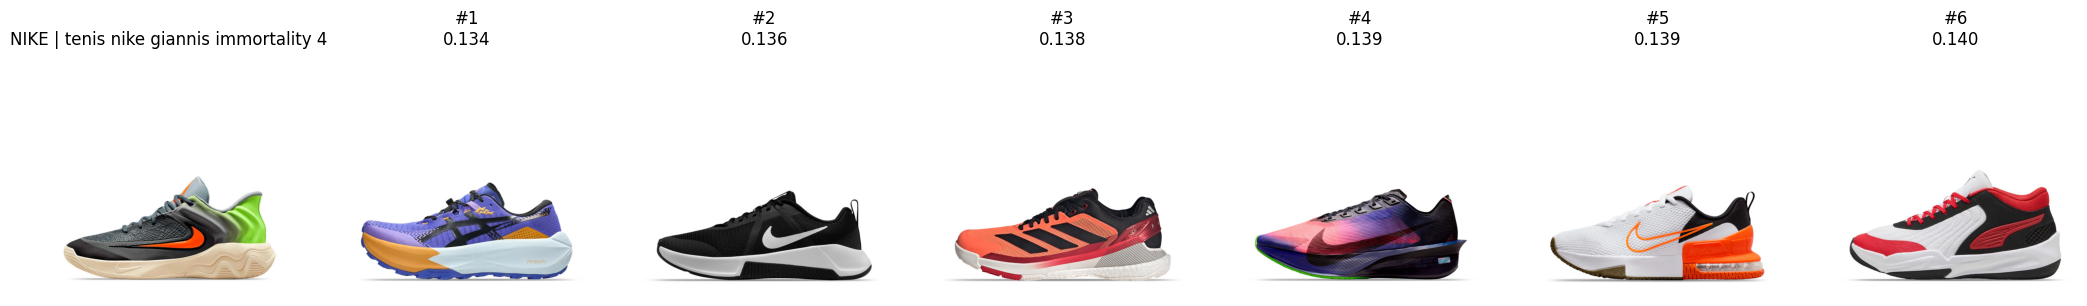

In [6]:
# Distancia coseno con embeddings normalizados: d = 1 - cos_sim
sim_matrix = embeddings @ embeddings.T
dist_matrix = 1.0 - sim_matrix

# Toma una imagen aleatoria como consulta en cada ejecucion
query_idx = np.random.randint(0, len(nombres))
k = 6

d = dist_matrix[query_idx].copy()
orden = np.argsort(d)
vecinos = [i for i in orden if i != query_idx][:k]

print(f'Indice consulta aleatoria: {query_idx}')
print('Consulta:', nombres[query_idx])
print('Vecinos mas cercanos:')
for rank, i in enumerate(vecinos, start=1):
    print(f'{rank}. {nombres[i]}  |  distancia={d[i]:.4f}')

fig, ax = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3))

img_q = Image.open(image_paths_valid[query_idx]).convert('RGB')
ax[0].imshow(img_q)
ax[0].set_title(nombres[query_idx])
ax[0].axis('off')

for j, i in enumerate(vecinos, start=1):
    img_v = Image.open(image_paths_valid[i]).convert('RGB')
    ax[j].imshow(img_v)
    ax[j].set_title(f'#{j}\n{d[i]:.3f}')
    ax[j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# ===== DINOv2 (ViT) como extractor de embeddings =====
# Sustituye ViT-B/16 por DINOv2. Mantengo nombres de variables (embeddings_vit, etc.)
# para que las celdas posteriores sigan funcionando.
import torchvision.transforms as T

# Recomendado: dinov2_vitb14 (mejor) o dinov2_vits14 (mas rapido)
dino_model_name = "dinov2_vitb14"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit = torch.hub.load("facebookresearch/dinov2", dino_model_name)
model_vit = model_vit.to(device).eval()

# Preprocesado estilo ImageNet; DINOv2 normalmente usa 224x224
tfm_vit = T.Compose(
    [
        T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)

embeddings_vit = []
nombres_vit = []
image_paths_valid_vit = []

with torch.no_grad():
    for path in image_paths:
        try:
            img = Image.open(path).convert("RGB")
            x = tfm_vit(img).unsqueeze(0).to(device)

            # Salida: (1, D). Para dinov2_vitb14, D=768.
            emb = model_vit(x).squeeze(0)
            emb = F.normalize(emb, dim=0)

            embeddings_vit.append(emb.detach().cpu().numpy())
            nombres_vit.append(file_meta_by_name.get(path.name, path.name))
            image_paths_valid_vit.append(path)
        except Exception:
            continue

if len(embeddings_vit) < 2:
    raise ValueError("Se requieren al menos 2 imagenes validas para comparar con DINOv2.")

embeddings_vit = np.stack(embeddings_vit, axis=0)  # (N, D)
print(f"DINOv2 ({dino_model_name}) embeddings extraidos:", embeddings_vit.shape)
print("Imagenes validas DINOv2:", len(image_paths_valid_vit))


Using cache found in C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 (dinov2_vitb14) embeddings extraidos: (167, 768)
Imagenes validas DINOv2: 167


Indice consulta aleatoria (ViT): 92
Consulta: NEW BALANCE | tenis new balance fuelcell rebel v5
Vecinos mas cercanos (ViT):
1. NEW BALANCE | tenis new balance fuelcell rebel v5  |  distancia=0.0510
2. NEW BALANCE | tenis new balance fuelcell supercomp elite v5  |  distancia=0.0668
3. NIKE | tenis nike run defy  |  distancia=0.0845
4. NIKE | tenis nike structure 26  |  distancia=0.0917
5. ASICS | tenis asics magic speed 5  |  distancia=0.0927
6. NEW BALANCE | tenis new balance ellipse v1  |  distancia=0.0939


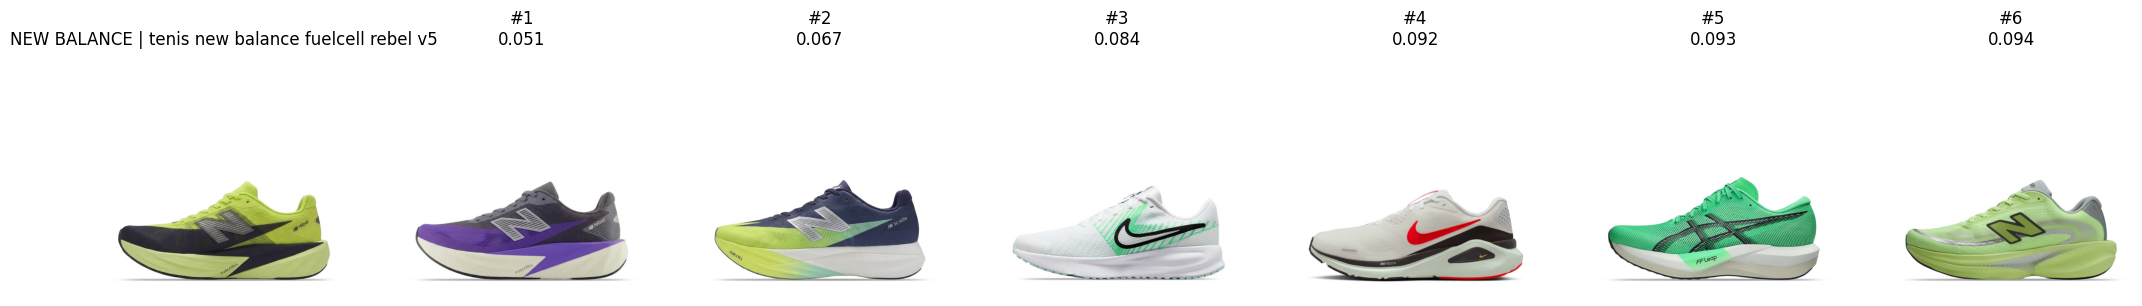

In [8]:
# ===== Vecinos mas cercanos usando ViT =====
sim_matrix_vit = embeddings_vit @ embeddings_vit.T
dist_matrix_vit = 1.0 - sim_matrix_vit

query_idx_vit = np.random.randint(0, len(nombres_vit))
k = 6

d_vit = dist_matrix_vit[query_idx_vit].copy()
orden_vit = np.argsort(d_vit)
vecinos_vit = [i for i in orden_vit if i != query_idx_vit][:k]

print(f"Indice consulta aleatoria (ViT): {query_idx_vit}")
print("Consulta:", nombres_vit[query_idx_vit])
print("Vecinos mas cercanos (ViT):")
for rank, i in enumerate(vecinos_vit, start=1):
    print(f"{rank}. {nombres_vit[i]}  |  distancia={d_vit[i]:.4f}")

fig, ax = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3))

img_q = Image.open(image_paths_valid_vit[query_idx_vit]).convert("RGB")
ax[0].imshow(img_q)
ax[0].set_title(nombres_vit[query_idx_vit])
ax[0].axis("off")

for j, i in enumerate(vecinos_vit, start=1):
    img_v = Image.open(image_paths_valid_vit[i]).convert("RGB")
    ax[j].imshow(img_v)
    ax[j].set_title(f"#{j}\n{d_vit[i]:.3f}")
    ax[j].axis("off")

plt.tight_layout()
plt.show()


=== ResNet18 ===
k por codo (usado): 5
Distribucion por cluster:
  Cluster 0: 58 imagenes
  Cluster 1: 25 imagenes
  Cluster 2: 39 imagenes
  Cluster 3: 10 imagenes
  Cluster 4: 35 imagenes


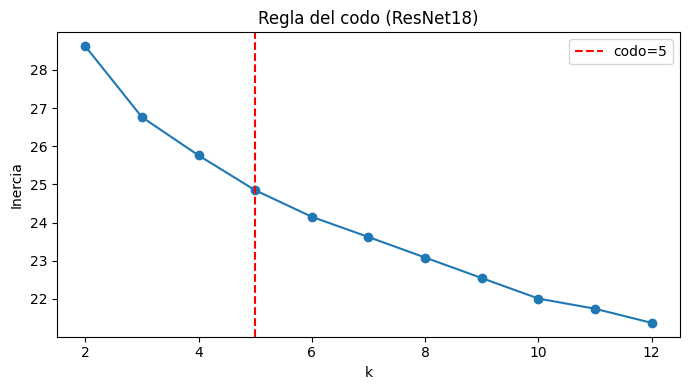

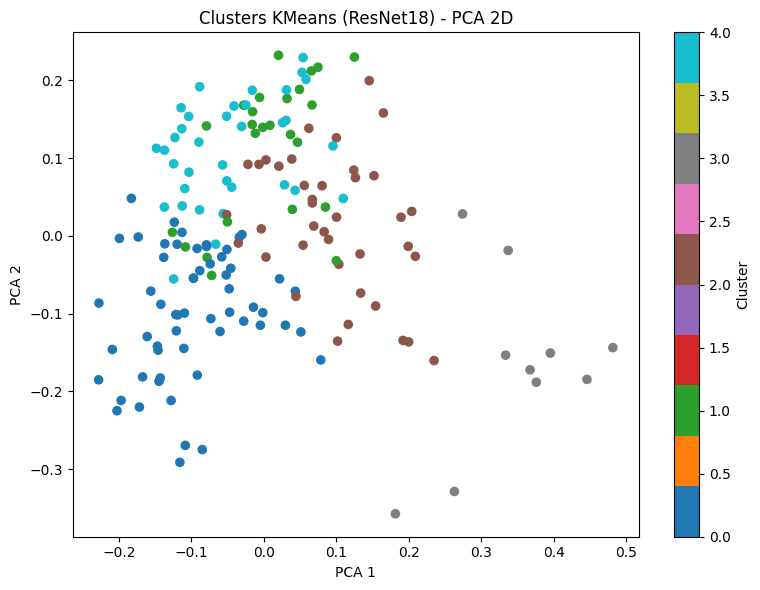

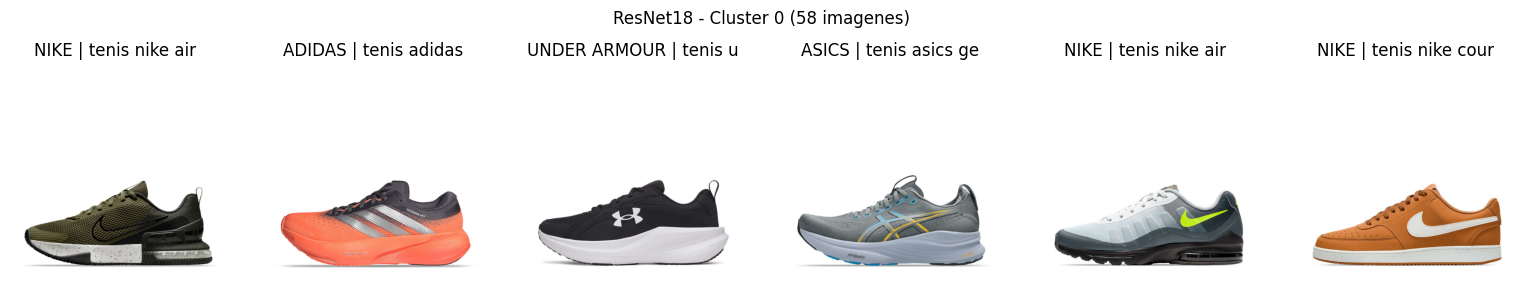

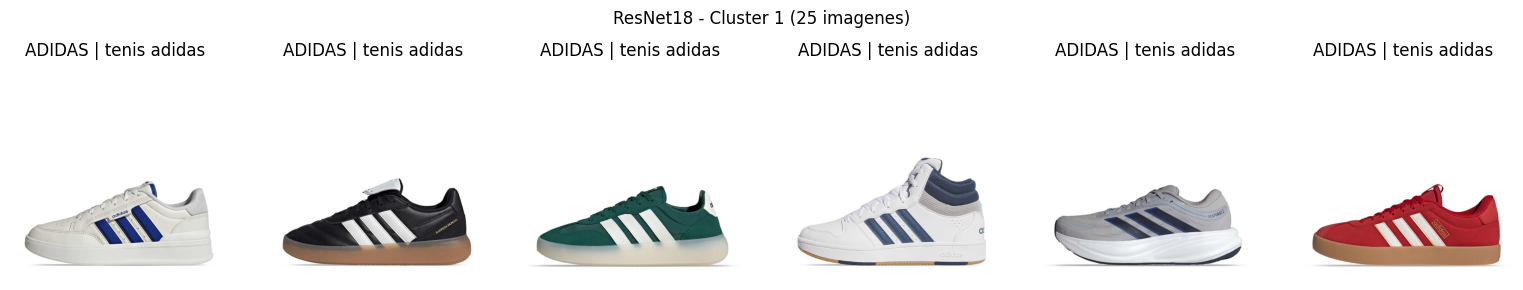

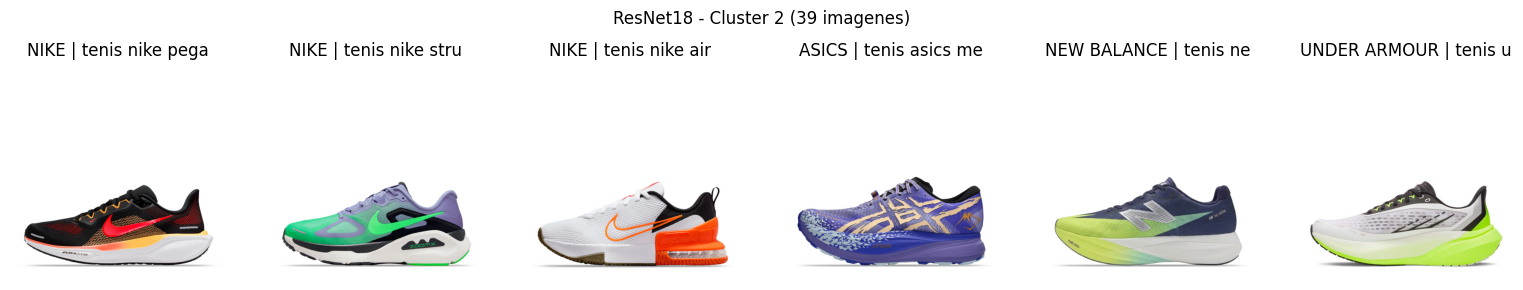

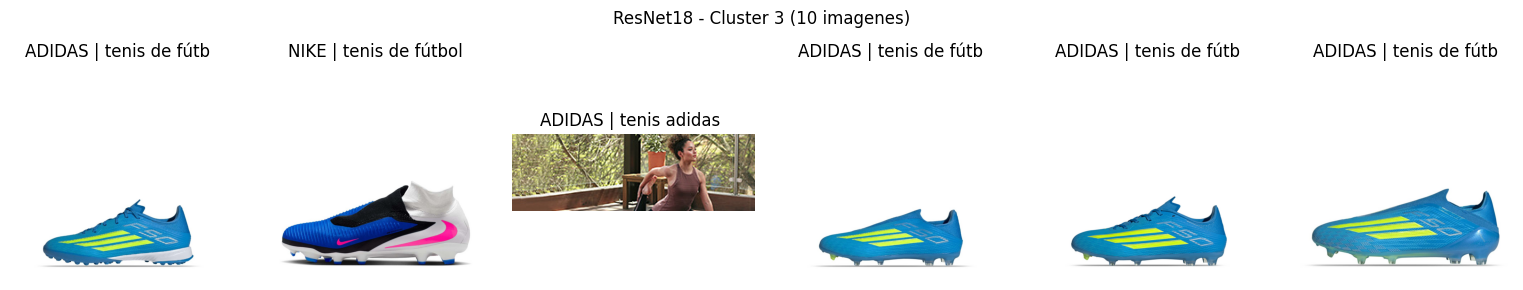

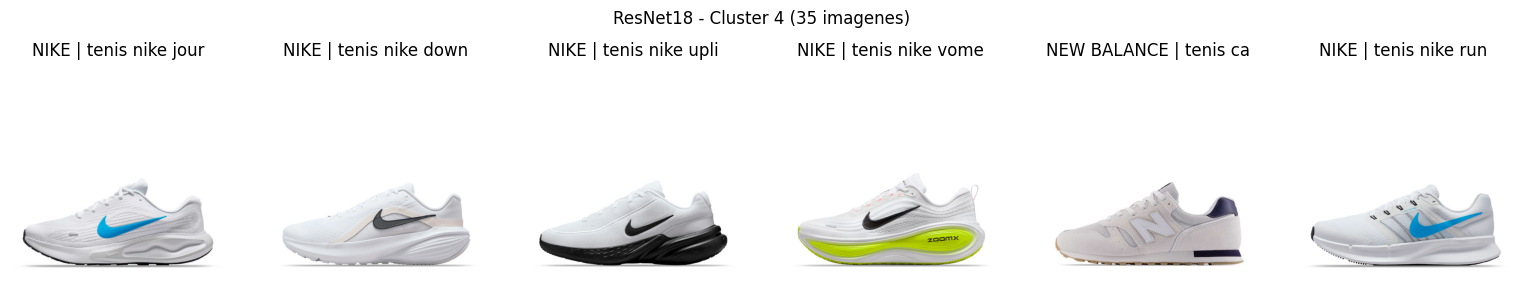


=== ViT-B/16 ===
k por codo (usado): 5
Distribucion por cluster:
  Cluster 0: 52 imagenes
  Cluster 1: 47 imagenes
  Cluster 2: 1 imagenes
  Cluster 3: 39 imagenes
  Cluster 4: 28 imagenes


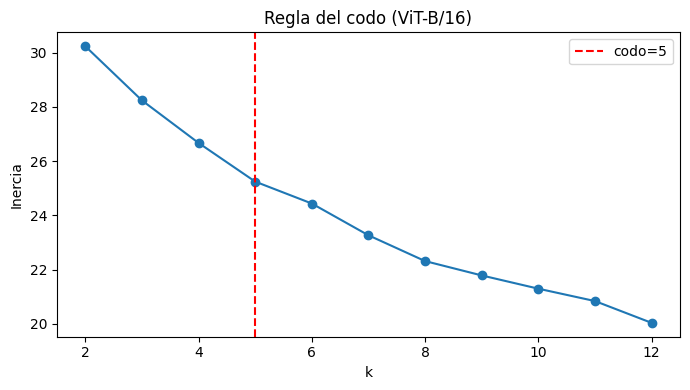

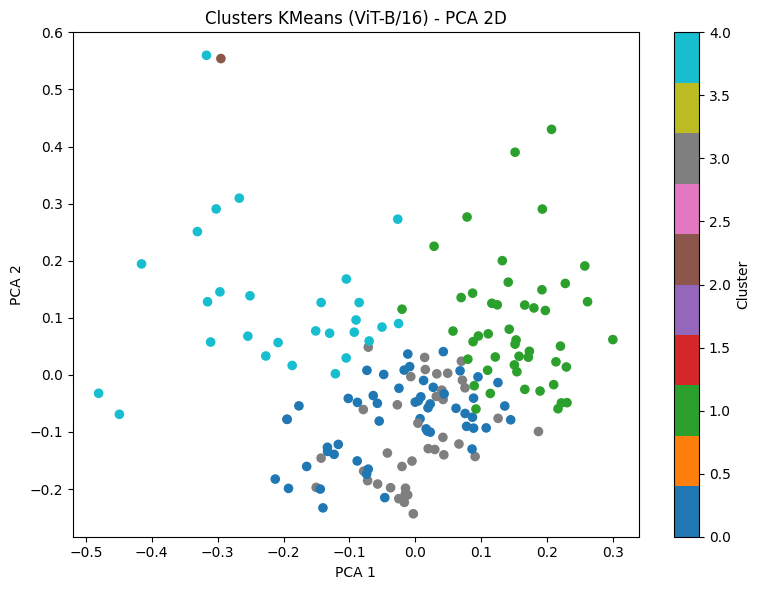

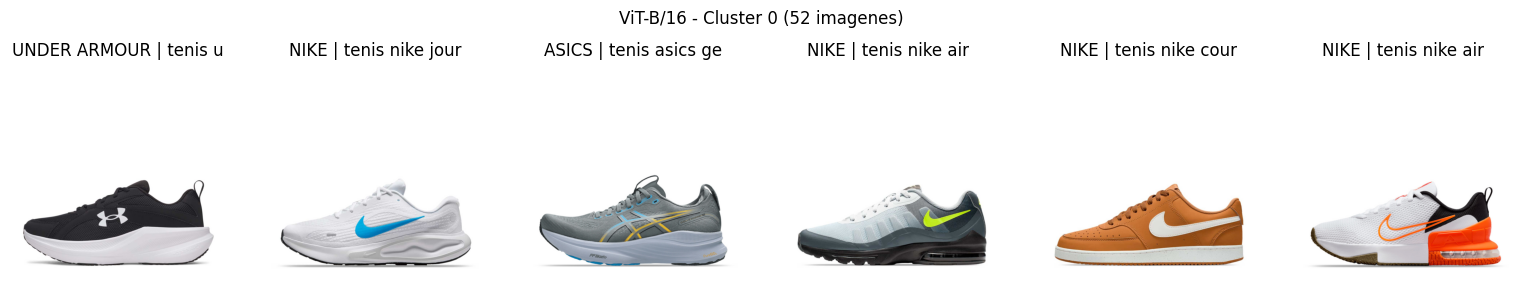

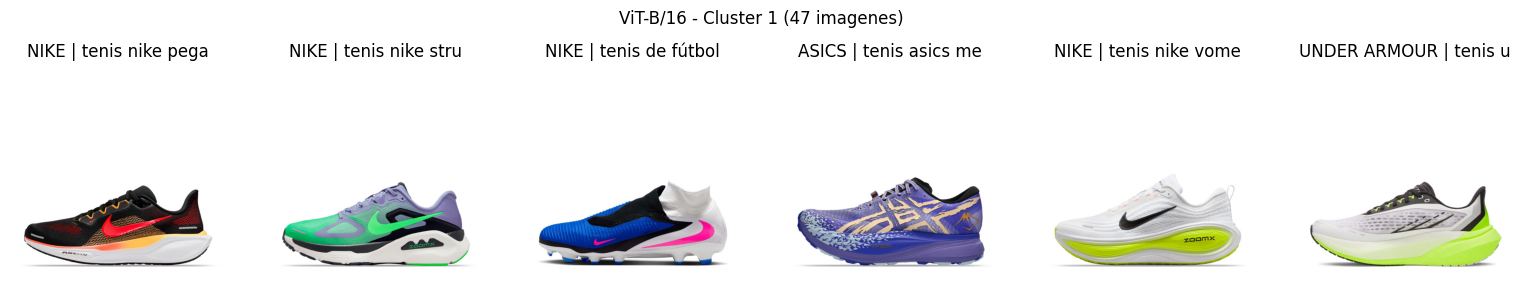

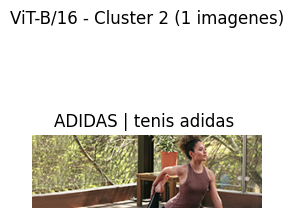

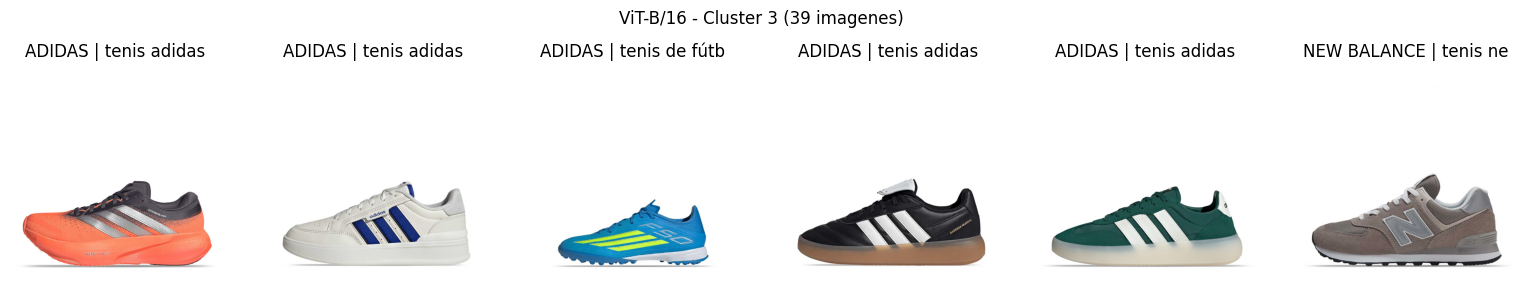

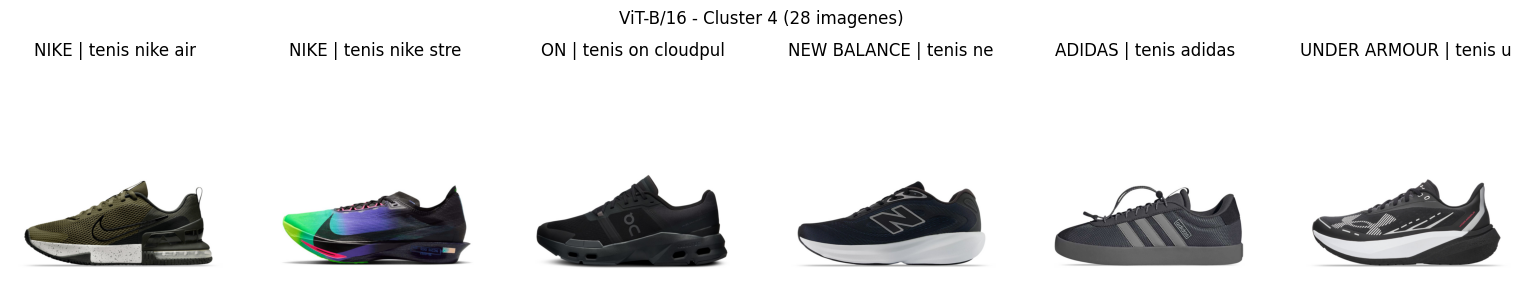

In [9]:
# ===== Seleccion de k con Regla del Codo para ResNet y ViT =====
def elbow_k_from_inertia(k_values, inertias):
    x = np.array(k_values, dtype=float)
    y = np.array(inertias, dtype=float)
    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]
    den = np.hypot(x2 - x1, y2 - y1)

    if den == 0:
        return k_values[0]

    dists = []
    for xi, yi in zip(x, y):
        num = abs((y2 - y1) * xi - (x2 - x1) * yi + x2 * y1 - y2 * x1)
        dists.append(num / den)
    return k_values[int(np.argmax(dists))]


def plot_cluster_examples(cluster_ids, image_paths_model, nombres_modelo, nombre_modelo, max_per_cluster=6):
    unique_clusters = sorted(np.unique(cluster_ids))
    for c in unique_clusters:
        idxs = np.where(cluster_ids == c)[0]
        if len(idxs) == 0:
            continue

        show_idxs = idxs[:max_per_cluster]
        n_show = len(show_idxs)
        fig, axes = plt.subplots(1, n_show, figsize=(2.6 * n_show, 2.8))
        if n_show == 1:
            axes = [axes]

        for ax, idx in zip(axes, show_idxs):
            try:
                img = Image.open(image_paths_model[idx]).convert('RGB')
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, 'No image', ha='center', va='center')
            ax.set_title(nombres_modelo[idx][:22])
            ax.axis('off')

        fig.suptitle(f'{nombre_modelo} - Cluster {c} ({len(idxs)} imagenes)', y=1.02)
        plt.tight_layout()
        plt.show()


def cluster_with_elbow(emb_matrix, nombres_modelo, image_paths_model, nombre_modelo):
    if len(emb_matrix) < 10:
        raise ValueError(f'Se requieren mas embeddings para clustering robusto en {nombre_modelo}.')

    k_min = 2
    k_max = min(12, len(emb_matrix) - 1)
    k_values = list(range(k_min, k_max + 1))

    inertias = []
    fitted = {}

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(emb_matrix)
        fitted[k] = (km, labels)
        inertias.append(km.inertia_)

    # Seleccion principal por codo
    k_codo = elbow_k_from_inertia(k_values, inertias)
    kmeans, cluster_ids = fitted[k_codo]

    print(f'\n=== {nombre_modelo} ===')
    print(f'k por codo (usado): {k_codo}')
    print('Distribucion por cluster:')
    for c in range(k_codo):
        count = int((cluster_ids == c).sum())
        print(f'  Cluster {c}: {count} imagenes')

    # Curva de codo
    plt.figure(figsize=(7, 4))
    plt.plot(k_values, inertias, marker='o')
    plt.axvline(k_codo, color='red', linestyle='--', label=f'codo={k_codo}')
    plt.title(f'Regla del codo ({nombre_modelo})')
    plt.xlabel('k')
    plt.ylabel('Inercia')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PCA 2D
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(emb_matrix)

    plt.figure(figsize=(8, 6))
    plt.scatter(emb_pca[:, 0], emb_pca[:, 1], c=cluster_ids, s=35, cmap='tab10')
    plt.title(f'Clusters KMeans ({nombre_modelo}) - PCA 2D')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.colorbar(label='Cluster')
    plt.tight_layout()
    plt.show()

    # Visualizaciones por cluster con imagenes reales
    plot_cluster_examples(cluster_ids, image_paths_model, nombres_modelo, nombre_modelo, max_per_cluster=6)

    return {
        'k_codo': k_codo,
        'cluster_ids': cluster_ids,
        'kmeans': kmeans
    }


resnet_cluster_info = cluster_with_elbow(embeddings, nombres, image_paths_valid, 'ResNet18')
vit_cluster_info = cluster_with_elbow(embeddings_vit, nombres_vit, image_paths_valid_vit, 'ViT-B/16')